In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

diabetes_ds = load_diabetes()
df = pd.DataFrame(diabetes_ds.data, columns=diabetes_ds.feature_names)
X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans_initial = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_initial = kmeans_initial.fit_predict(X_scaled)

unique, counts = np.unique(labels_initial, return_counts=True)
cluster_sizes_initial = dict(zip(unique, counts))

sil_score_initial = silhouette_score(X_scaled, labels_initial)
ch_score_initial = calinski_harabasz_score(X_scaled, labels_initial)
db_score_initial = davies_bouldin_score(X_scaled, labels_initial)

print(f"k = 3")
print(f"Cluster sizes: {cluster_sizes_initial}")
print(f"Silhouette score: {sil_score_initial:.4f}")
print(f"Calinski-Harabasz index: {ch_score_initial:.4f}")
print(f"Davies-Bouldin index: {db_score_initial:.4f}")

k = 3
Cluster sizes: {np.int32(0): np.int64(125), np.int32(1): np.int64(159), np.int32(2): np.int64(158)}
Silhouette score: 0.1535
Calinski-Harabasz index: 117.4638
Davies-Bouldin index: 1.9826


In [3]:
k_values = [2, 3, 4, 5, 6]
results_kmeans = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    inertia = km.inertia_
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    
    results_kmeans.append([k, inertia, sil, ch, db])

df_kmeans_results = pd.DataFrame(results_kmeans, columns=["k", "Inertia", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])
display(df_kmeans_results)

,k,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,3176.654907,0.236987,172.216327,1.545465
1,3,2879.211235,0.153473,117.463814,1.982649
2,4,2642.689445,0.137191,98.190630,1.976898
3,5,2453.238587,0.146746,87.585727,1.855202
4,6,2307.607219,0.143004,79.823225,1.791635


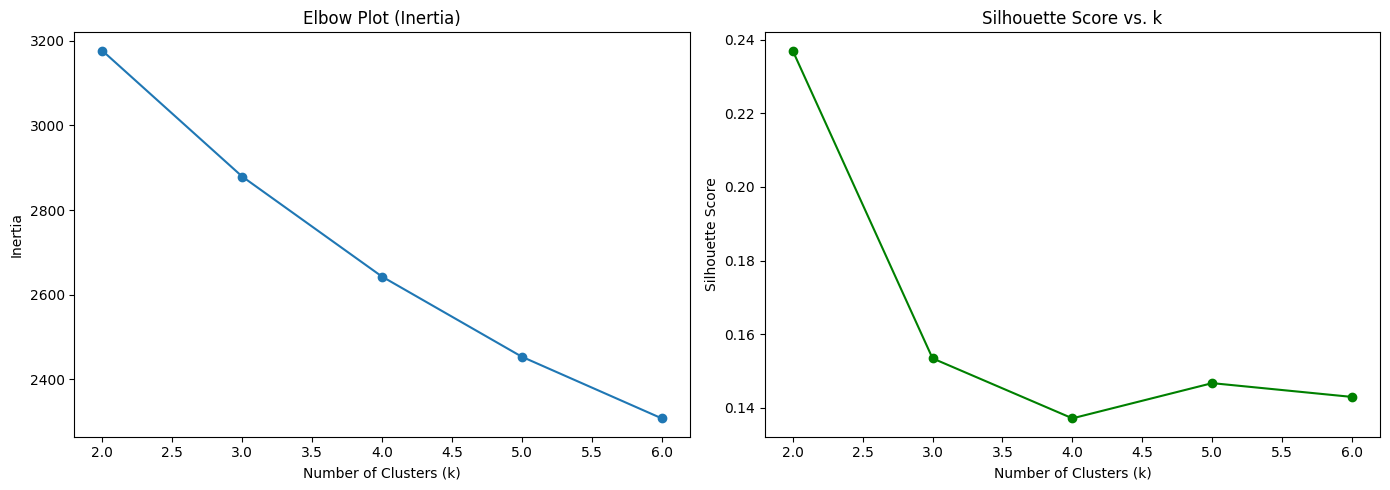

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_kmeans_results["k"], df_kmeans_results["Inertia"], marker='o')
axes[0].set_title("Elbow Plot (Inertia)")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(df_kmeans_results["k"], df_kmeans_results["Silhouette"], marker='o', color='green')
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [5]:
## The elbow method indicates a slight bend at k=2, which perfectly aligns with the internal evaluation metrics, 
# as k=2 yields the highest Silhouette score and the lowest Davies-Bouldin index. While Calinski-Harabasz is also strong at k=2, 
# the agreement across the metrics suggests that dividing the data into two main groups provides the most distinct clustering structure.

In [6]:
best_k = 2
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
best_labels = kmeans_best.fit_predict(X_scaled)

unique_best, counts_best = np.unique(best_labels, return_counts=True)
cluster_sizes_best = dict(zip(unique_best, counts_best))

centroids = scaler.inverse_transform(kmeans_best.cluster_centers_)
df_centroids = pd.DataFrame(centroids, columns=df.columns)

print(f"Final number of clusters: {best_k}")
print(f"Cluster sizes: {cluster_sizes_best}")
display(df_centroids)

Final number of clusters: 2
Cluster sizes: {np.int32(0): np.int64(214), np.int32(1): np.int64(228)}


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,-0.017855,-0.016134,-0.025168,-0.021903,-0.025777,-0.027574,0.026387,-0.035543,-0.031945,-0.026143
1,0.016759,0.015143,0.023623,0.020559,0.024194,0.025881,-0.024767,0.033360,0.029984,0.024538


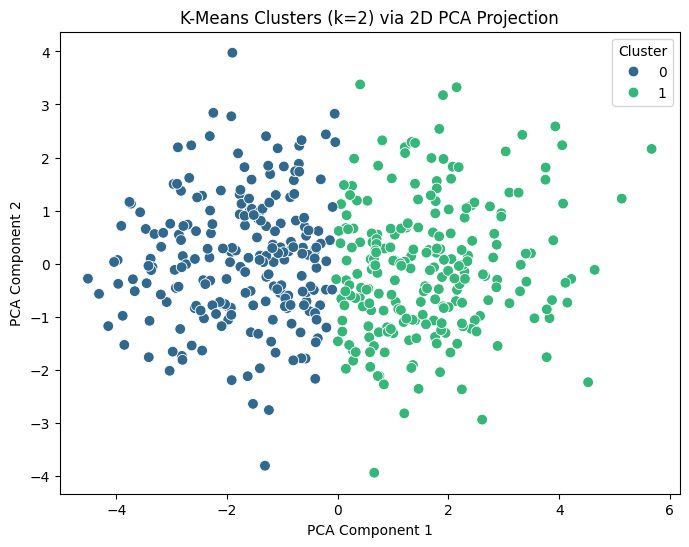

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=best_labels, palette="viridis", s=60)
plt.title("K-Means Clusters (k=2) via 2D PCA Projection")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

In [8]:
## The clusters differentiate patients primarily by their overall metabolic profiles, 
# with the centroids showing distinct differences in variables like BMI and blood pressure. 
# The clusters are relatively well-balanced in size, but because human health data is highly continuous, 
# the PCA projection shows them touching in the center rather than forming distinct, isolated islands.

In [9]:
dbscan = DBSCAN(eps=3.0, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
sil_db = silhouette_score(X_scaled, labels_db) if n_clusters_db > 1 else np.nan
ch_db = calinski_harabasz_score(X_scaled, labels_db) if n_clusters_db > 1 else np.nan
db_idx_db = davies_bouldin_score(X_scaled, labels_db) if n_clusters_db > 1 else np.nan

hc = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)

sil_hc = silhouette_score(X_scaled, labels_hc)
ch_hc = calinski_harabasz_score(X_scaled, labels_hc)
db_idx_hc = davies_bouldin_score(X_scaled, labels_hc)

comparison_data = [
    ["K-Means", "k=2", 2, df_kmeans_results.loc[0, "Silhouette"], df_kmeans_results.loc[0, "Calinski-Harabasz"], df_kmeans_results.loc[0, "Davies-Bouldin"]],
    ["Hierarchical", "linkage=ward, k=2", 2, sil_hc, ch_hc, db_idx_hc],
    ["DBSCAN", "eps=3.0, min_samples=5", f"{n_clusters_db} (+ noise)", sil_db, ch_db, db_idx_db]
]

df_comparison = pd.DataFrame(comparison_data, columns=["Model", "Main Parameters", "Clusters Found", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])
display(df_comparison)

,Model,Main Parameters,Clusters Found,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,K-Means,k=2,2,0.236987,172.216327,1.545465
1,Hierarchical,"linkage=ward, k=2",2,0.179950,122.009599,1.730710
2,DBSCAN,"eps=3.0, min_samples=5",1 (+ noise),NaN,NaN,NaN


In [ ]:
### The criteria mostly agreed that K-Means and Hierarchical (Ward) performed well, with Calinski-Harabasz slightly favoring K-Means.
#  They may differ because each metric measures clustering quality differently (e.g., separation vs compactness).

In [ ]:
## K-Means is simple and produces clear clusters without labeling points as noise like DBSCAN. 
# However, it assumes spherical clusters, which may not match the true structure of the data.

In [ ]:
## K-Means (k=2) is the best choice for this dataset. 
# The data does not form clear dense regions for DBSCAN, and K-Means provides stable and interpretable clusters. 
# It is also easy to tune using methods like the elbow and silhouette score.